<a href="https://colab.research.google.com/github/Nicolas-1802/ColabProjects/blob/main/Trabalho%20M2%20-%20Processamento%20de%20Imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto M2 - Processamento de Imagens
# Segmentação clássica de lesões de pele - ISIC
# Alunos: Gabrielly C. de Andrade e Nicolas F. Teixeira

In [23]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

1. Download automático do dataset


In [24]:
!pip install -q kagglehub

In [25]:
DATASET_PATH = kagglehub.dataset_download("paultimothymooney/blood-cells")

print("Dataset baixado em:")
print(DATASET_PATH)

# Procura imagens
image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_files.extend(glob.glob(DATASET_PATH + "/**/" + ext, recursive=True))

image_files = sorted(image_files)

print("Total de imagens encontradas:", len(image_files))

print("\nPrimeiras imagens encontradas:")
for p in image_files[:10]:
    print(p)

if len(image_files) == 0:
    raise Exception("Nenhuma imagem foi encontrada. Verifique se o dataset baixou corretamente.")

Using Colab cache for faster access to the 'blood-cells' dataset.
Dataset baixado em:
/kaggle/input/blood-cells
Total de imagens encontradas: 12881

Primeiras imagens encontradas:
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00000.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00001.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00002.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00003.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00004.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00005.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00006.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00007.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00008.jpg
/kaggle/input/blood-cells/da

2. Funções básicas de leitura e conversão

In [26]:
def load_image(path, size=(256, 256)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.asarray(img).astype(np.float32) / 255.0


def rgb_to_gray(img):
    return 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]


def normalize01(x):
    x = x.astype(np.float32)
    mn = x.min()
    mx = x.max()

    if mx - mn < 1e-8:
        return np.zeros_like(x)

    return (x - mn) / (mx - mn)

3. Conversão RGB para HSV

In [27]:
def rgb_to_hsv_manual(img):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    maxc = np.maximum(np.maximum(r, g), b)
    minc = np.minimum(np.minimum(r, g), b)
    delta = maxc - minc

    h = np.zeros_like(maxc)

    mask = delta > 1e-8

    idx = mask & (maxc == r)
    h[idx] = ((g[idx] - b[idx]) / delta[idx]) % 6

    idx = mask & (maxc == g)
    h[idx] = ((b[idx] - r[idx]) / delta[idx]) + 2

    idx = mask & (maxc == b)
    h[idx] = ((r[idx] - g[idx]) / delta[idx]) + 4

    h = h / 6.0

    s = np.zeros_like(maxc)
    s[maxc > 1e-8] = delta[maxc > 1e-8] / maxc[maxc > 1e-8]

    v = maxc

    hsv = np.stack([h, s, v], axis=2)
    return hsv

4. Filtro passa-baixa no domínio da frequência

In [28]:
def low_pass_fft(gray, radius=30):
    h, w = gray.shape

    F = np.fft.fft2(gray)
    F_shift = np.fft.fftshift(F)

    cy = h // 2
    cx = w // 2

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)

    mask = dist <= radius

    F_filtered = F_shift * mask

    img_back = np.fft.ifft2(np.fft.ifftshift(F_filtered))
    img_back = np.abs(img_back)

    return normalize01(img_back)

5. Otsu

In [29]:
def otsu_threshold(image):
    """
    Implementação manual do método de Otsu.
    Baseada na versão didática do notebook do professor.

    Entrada:
    - image: imagem uint8 ou array com valores entre 0 e 255

    Saída:
    - threshold: limiar ótimo entre 0 e 255
    """

    image = image.astype(np.uint8)

    hist = np.bincount(image.ravel(), minlength=256)
    total = image.size

    sum_total = np.sum(np.arange(256) * hist)

    sum_b = 0
    weight_b = 0

    max_variance = 0
    threshold = 0

    for t in range(256):
        weight_b += hist[t]

        if weight_b == 0:
            continue

        weight_f = total - weight_b

        if weight_f == 0:
            break

        sum_b += t * hist[t]

        mean_b = sum_b / weight_b
        mean_f = (sum_total - sum_b) / weight_f

        var_between = weight_b * weight_f * (mean_b - mean_f) ** 2

        if var_between > max_variance:
            max_variance = var_between
            threshold = t

    return threshold


def apply_threshold(image, threshold):
    """
    Aplica limiarização binária.
    Retorna máscara com valores 0 e 1.
    """

    image = image.astype(np.uint8)
    return (image >= threshold).astype(np.uint8)

6. SLIC

In [41]:
def initialize_clusters(image, S):
    h, w = image.shape[:2]

    clusters = []

    for y in range(S // 2, h, S):
        for x in range(S // 2, w, S):
            pixel = image[y, x]

            if image.ndim == 2:
                color = float(pixel)
            else:
                color = pixel.astype(float)

            clusters.append([float(y), float(x), color])

    return clusters


def compute_slic_distance(y, x, cluster, image, S, m):
    yc, xc, ic = cluster

    ds2 = (y - yc) ** 2 + (x - xc) ** 2

    pixel = image[y, x]

    if image.ndim == 2:
        dc2 = (float(pixel) - float(ic)) ** 2
    else:
        dc2 = np.sum((pixel.astype(float) - np.asarray(ic, dtype=float)) ** 2)

    distance = np.sqrt(dc2 + ((m / S) ** 2) * ds2)

    return distance


def slic_from_scratch(image, num_superpixels=300, m=10, max_iter=8):
    h, w = image.shape[:2]

    S = max(1, int(np.sqrt((h * w) / num_superpixels)))

    clusters = initialize_clusters(image, S)

    K = len(clusters)

    labels = -np.ones((h, w), dtype=np.int32)
    distances = np.full((h, w), np.inf)

    for iteration in range(max_iter):

        for k, cluster in enumerate(clusters):
            yc, xc, _ = cluster

            y0 = int(max(yc - S, 0))
            y1 = int(min(yc + S, h))

            x0 = int(max(xc - S, 0))
            x1 = int(min(xc + S, w))

            for y in range(y0, y1):
                for x in range(x0, x1):
                    d = compute_slic_distance(
                        y,
                        x,
                        cluster,
                        image,
                        S,
                        m
                    )

                    if d < distances[y, x]:
                        distances[y, x] = d
                        labels[y, x] = k

        new_clusters = []

        for k in range(K):
            ys, xs = np.where(labels == k)

            if len(ys) == 0:
                new_clusters.append(clusters[k])
                continue

            yc = np.mean(ys)
            xc = np.mean(xs)

            if image.ndim == 2:
                ic = np.mean(image[ys, xs])
            else:
                ic = np.mean(image[ys, xs], axis=0)

            new_clusters.append([yc, xc, ic])

        clusters = new_clusters

        distances.fill(np.inf)

    return labels

7. Morfologia matemática from scratch


In [31]:
def binary_erosion(mask, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(mask, pad, mode="constant", constant_values=0)

    h, w = mask.shape
    out = np.zeros_like(mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kernel_size, x:x + kernel_size]

            if np.all(region == 1):
                out[y, x] = 1

    return out


def binary_dilation(mask, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(mask, pad, mode="constant", constant_values=0)

    h, w = mask.shape
    out = np.zeros_like(mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kernel_size, x:x + kernel_size]

            if np.any(region == 1):
                out[y, x] = 1

    return out


def opening(mask, kernel_size=3):
    return binary_dilation(binary_erosion(mask, kernel_size), kernel_size)


def closing(mask, kernel_size=3):
    return binary_erosion(binary_dilation(mask, kernel_size), kernel_size)


def connected_components(mask):
    h, w = mask.shape

    labels = np.zeros((h, w), dtype=np.int32)
    current_label = 0
    areas = {}

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 1 and labels[y, x] == 0:
                current_label += 1

                stack = [(y, x)]
                labels[y, x] = current_label
                area = 0

                while len(stack) > 0:
                    cy, cx = stack.pop()
                    area += 1

                    for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        ny = cy + dy
                        nx = cx + dx

                        if 0 <= ny < h and 0 <= nx < w:
                            if mask[ny, nx] == 1 and labels[ny, nx] == 0:
                                labels[ny, nx] = current_label
                                stack.append((ny, nx))

                areas[current_label] = area

    return labels, areas


def remove_small_components(mask, min_area=80):
    labels, areas = connected_components(mask)

    out = np.zeros_like(mask)

    for lab, area in areas.items():
        if area >= min_area:
            out[labels == lab] = 1

    return out


def fill_holes(mask):
    h, w = mask.shape

    inv = 1 - mask
    visited = np.zeros_like(inv, dtype=np.uint8)

    stack = []

    for x in range(w):
        if inv[0, x] == 1:
            stack.append((0, x))
            visited[0, x] = 1

        if inv[h - 1, x] == 1:
            stack.append((h - 1, x))
            visited[h - 1, x] = 1

    for y in range(h):
        if inv[y, 0] == 1:
            stack.append((y, 0))
            visited[y, 0] = 1

        if inv[y, w - 1] == 1:
            stack.append((y, w - 1))
            visited[y, w - 1] = 1

    while len(stack) > 0:
        cy, cx = stack.pop()

        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny = cy + dy
            nx = cx + dx

            if 0 <= ny < h and 0 <= nx < w:
                if inv[ny, nx] == 1 and visited[ny, nx] == 0:
                    visited[ny, nx] = 1
                    stack.append((ny, nx))

    holes = (inv == 1) & (visited == 0)

    filled = mask.copy()
    filled[holes] = 1

    return filled.astype(np.uint8)


8. SCORE PARA DESTACAR CÉLULAS

In [32]:
def blood_cell_score(img):
    hsv = rgb_to_hsv_manual(img)

    gray = rgb_to_gray(img)
    saturation = hsv[:, :, 1]

    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    # Fundo claro fica próximo de branco.
    distance_from_white = np.sqrt(
        (1.0 - r) ** 2 +
        (1.0 - g) ** 2 +
        (1.0 - b) ** 2
    )
    distance_from_white = normalize01(distance_from_white)

    # Células costumam ter mais saturação que o fundo.
    sat_score = normalize01(saturation)

    # Partes celulares são geralmente mais escuras que o fundo.
    dark_score = normalize01(1.0 - gray)

    # Realça células rosadas/arroxeadas.
    color_score = normalize01((r + b) / 2.0 - g)

    score = (
        0.35 * distance_from_white +
        0.30 * sat_score +
        0.20 * dark_score +
        0.15 * color_score
    )

    return normalize01(score)

9. SEGMENTAÇÃO POR SUPERPIXEL + OTSU

In [42]:
def segment_by_superpixel_otsu(img, labels, score_img):
    unique_labels = np.unique(labels)

    superpixel_values = []

    for lab in unique_labels:
        region = labels == lab
        value = score_img[region].mean()
        superpixel_values.append(value)

    superpixel_values = np.array(superpixel_values)

    # Converte scores 0-1 para 0-255 para usar o Otsu do professor
    values_uint8 = np.clip(superpixel_values * 255, 0, 255).astype(np.uint8)

    threshold = otsu_threshold_manual(values_uint8)

    mask = np.zeros(labels.shape, dtype=np.uint8)

    for lab, value in zip(unique_labels, values_uint8):
        if value >= threshold:
            mask[labels == lab] = 1

    # Controle para evitar segmentação exagerada
    if mask.mean() > 0.65:
        threshold = np.percentile(values_uint8, 70)

        mask = np.zeros(labels.shape, dtype=np.uint8)

        for lab, value in zip(unique_labels, values_uint8):
            if value >= threshold:
                mask[labels == lab] = 1

    return mask

In [34]:
def superpixel_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)

    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1]:
                boundaries[y, x] = 1
            if labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 1

    return boundaries

In [43]:
def overlay_mask_on_image(img, mask, alpha=0.45):
    if img.shape[:2] != mask.shape:
        raise ValueError(
            f"Tamanho diferente: imagem {img.shape[:2]} e máscara {mask.shape}"
        )

    overlay = img.copy()

    # Cor vermelha para a região segmentada
    red_mask = np.zeros_like(img)
    red_mask[:, :, 0] = 1.0

    mask_bool = mask.astype(bool)

    overlay[mask_bool] = (
        (1 - alpha) * img[mask_bool] +
        alpha * red_mask[mask_bool]
    )

    return np.clip(overlay, 0, 1)

10. PÓS-PROCESSAMENTO MORFOLÓGICO

In [36]:
def post_process(mask):
    result = opening(mask, kernel_size=3)
    result = closing(result, kernel_size=5)
    result = fill_holes(result)
    result = remove_small_components(result, min_area=80)
    result = closing(result, kernel_size=5)

    return result.astype(np.uint8)

11. AVALIAÇÃO QUANTITATIVA

In [37]:
def evaluate_segmentation(raw_mask, final_mask):
    raw_labels, raw_areas = connected_components(raw_mask)
    final_labels, final_areas = connected_components(final_mask)

    raw_count = len(raw_areas)
    final_count = len(final_areas)

    removed_objects = raw_count - final_count

    total_pixels = final_mask.shape[0] * final_mask.shape[1]
    segmented_pixels = final_mask.sum()

    if final_count == 0:
        return {
            "Objetos_antes_pos_processamento": raw_count,
            "Objetos_finais_segmentados": 0,
            "Objetos_removidos": removed_objects,
            "Area_total_segmentada": 0,
            "Area_media_dos_objetos": 0,
            "Maior_objeto": 0,
            "Menor_objeto": 0,
            "Percentual_imagem_segmentada": 0
        }

    area_values = list(final_areas.values())

    return {
        "Objetos_antes_pos_processamento": raw_count,
        "Objetos_finais_segmentados": final_count,
        "Objetos_removidos": removed_objects,
        "Area_total_segmentada": int(np.sum(area_values)),
        "Area_media_dos_objetos": float(np.mean(area_values)),
        "Maior_objeto": int(np.max(area_values)),
        "Menor_objeto": int(np.min(area_values)),
        "Percentual_imagem_segmentada": float(segmented_pixels / total_pixels)
    }

12. Seleção automática de 5 imagens difíceis

In [38]:
def difficulty_score(img_path):
    img = load_image(img_path)

    gray = rgb_to_gray(img)
    hsv = rgb_to_hsv_manual(img)

    saturation = hsv[:, :, 1]

    # Baixo contraste global
    contrast = gray.std()

    # Alta variação de saturação indica coloração mais complexa
    sat_var = saturation.std()

    # Score de cor
    score = blood_cell_score(img)

    # Quanto mais ambígua a separação por Otsu, mais difícil
    t = otsu_threshold(score.flatten())
    foreground = score >= t
    area_ratio = foreground.mean()

    area_difficulty = 1.0 - abs(area_ratio - 0.25)

    # Dificuldade final
    difficulty = (
        0.35 * (1.0 / (contrast + 1e-6)) +
        0.35 * sat_var +
        0.30 * area_difficulty
    )

    return difficulty


scored = []

# Analisa uma amostra do dataset para não demorar muito
candidate_files = image_files[:300]

for p in candidate_files:
    try:
        s = difficulty_score(p)
        scored.append((s, p))
    except:
        pass

scored = sorted(scored, reverse=True, key=lambda x: x[0])

NUM_IMAGES = 5
selected_images = [p for s, p in scored[:NUM_IMAGES]]

print("\nImagens difíceis selecionadas:")
for s, p in scored[:NUM_IMAGES]:
    print(f"{os.path.basename(p)} | dificuldade = {s:.4f}")


Imagens difíceis selecionadas:
BloodImage_00167.jpg | dificuldade = 6.1577
BloodImage_00253.jpg | dificuldade = 6.1015
BloodImage_00252.jpg | dificuldade = 6.0096
BloodImage_00281.jpg | dificuldade = 6.0079
BloodImage_00164.jpg | dificuldade = 5.6130


11. Pipeline completo


Processando imagem: 1
BloodImage_00167.jpg
Pixels alterados pela morfologia: 2990
Percentual alterado: 0.045623779296875
Métricas da imagem:
Objetos_antes_pos_processamento: 25
Objetos_finais_segmentados: 15
Objetos_removidos: 10
Area_total_segmentada: 22407
Area_media_dos_objetos: 1493.8
Maior_objeto: 3724
Menor_objeto: 236
Percentual_imagem_segmentada: 0.3419036865234375
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_1.png


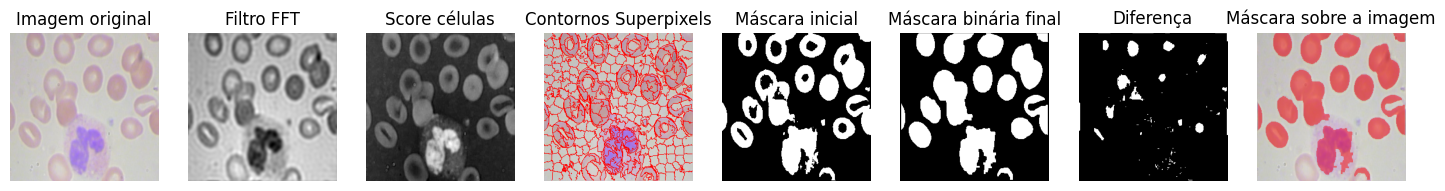


Processando imagem: 2
BloodImage_00253.jpg
Pixels alterados pela morfologia: 3028
Percentual alterado: 0.04620361328125
Métricas da imagem:
Objetos_antes_pos_processamento: 25
Objetos_finais_segmentados: 9
Objetos_removidos: 16
Area_total_segmentada: 28933
Area_media_dos_objetos: 3214.777777777778
Maior_objeto: 10937
Menor_objeto: 136
Percentual_imagem_segmentada: 0.4414825439453125
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_2.png


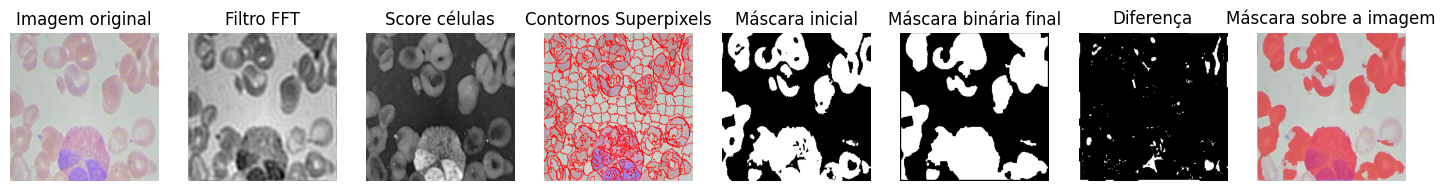


Processando imagem: 3
BloodImage_00252.jpg
Pixels alterados pela morfologia: 1581
Percentual alterado: 0.0241241455078125
Métricas da imagem:
Objetos_antes_pos_processamento: 45
Objetos_finais_segmentados: 22
Objetos_removidos: 23
Area_total_segmentada: 23183
Area_media_dos_objetos: 1053.7727272727273
Maior_objeto: 7543
Menor_objeto: 117
Percentual_imagem_segmentada: 0.3537445068359375
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_3.png


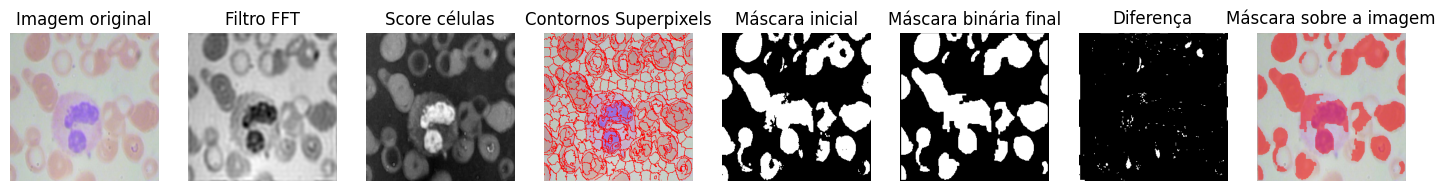


Processando imagem: 4
BloodImage_00281.jpg
Pixels alterados pela morfologia: 1329
Percentual alterado: 0.0202789306640625
Métricas da imagem:
Objetos_antes_pos_processamento: 26
Objetos_finais_segmentados: 17
Objetos_removidos: 9
Area_total_segmentada: 16223
Area_media_dos_objetos: 954.2941176470588
Maior_objeto: 6378
Menor_objeto: 114
Percentual_imagem_segmentada: 0.2475433349609375
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_4.png


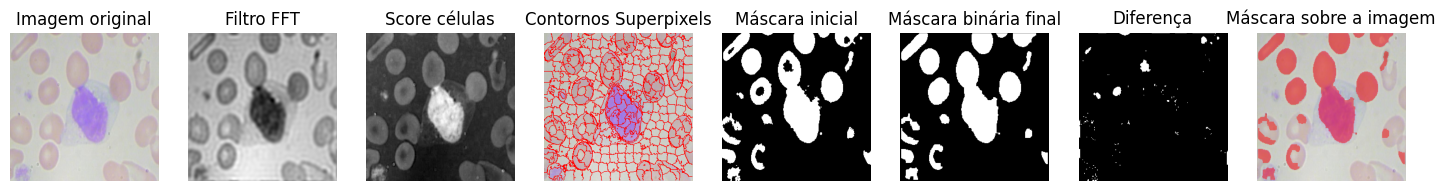


Processando imagem: 5
BloodImage_00164.jpg
Pixels alterados pela morfologia: 3087
Percentual alterado: 0.0471038818359375
Métricas da imagem:
Objetos_antes_pos_processamento: 21
Objetos_finais_segmentados: 13
Objetos_removidos: 8
Area_total_segmentada: 31915
Area_media_dos_objetos: 2455.0
Maior_objeto: 12170
Menor_objeto: 86
Percentual_imagem_segmentada: 0.4869842529296875
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_5.png


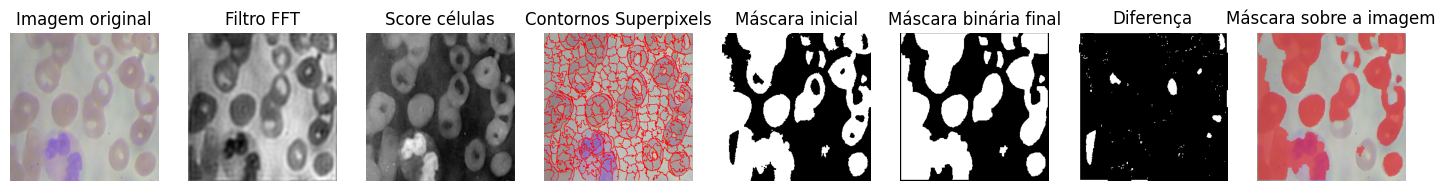

In [39]:
OUTPUT_DIR = "/content/mascaras_binarias_celulas"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_metrics = []

for idx, img_path in enumerate(selected_images):
    print("\n========================================")
    print("Processando imagem:", idx + 1)
    print(os.path.basename(img_path))
    print("========================================")

    img = load_image(img_path)

    gray = rgb_to_gray(img)

    # Etapa 1: pré-processamento e score de célula
    score_img = blood_cell_score(img)

    # Etapa 2: filtragem em frequência
    filtered_gray = low_pass_fft(gray, radius=28)

    # Etapa 3: segmentação por superpixels
    img_uint8 = np.clip(img * 255, 0, 255).astype(np.uint8)

    labels = slic_from_scratch(
        img_uint8,
        num_superpixels=300,
        m=10,
        max_iter=8
    )

    raw_mask = segment_by_superpixel_otsu(
        img,
        labels,
        score_img
    )

    # Etapa 4: morfologia matemática
    final_mask = post_process(raw_mask)
    boundaries = superpixel_boundaries(labels)

    overlay_superpixels = img.copy()
    overlay_superpixels[boundaries == 1] = [1, 0, 0]
    mask_overlay = overlay_mask_on_image(img, final_mask)

    diferenca = np.abs(final_mask.astype(int) - raw_mask.astype(int))

    print("Pixels alterados pela morfologia:", diferenca.sum())
    print("Percentual alterado:", diferenca.sum() / diferenca.size)

    # Etapa 5: avaliação quantitativa
    metrics = evaluate_segmentation(raw_mask, final_mask)

    all_metrics.append(metrics)

    print("Métricas da imagem:")

    for key, value in metrics.items():
        print(f"{key}: {value}")

    # Salvar máscara binária
    mask_to_save = (final_mask * 255).astype(np.uint8)

    output_name = f"mascara_binaria_celulas_{idx + 1}.png"
    output_path = os.path.join(OUTPUT_DIR, output_name)

    Image.fromarray(mask_to_save).save(output_path)

    print("Máscara salva em:", output_path)

    # Visualização
    plt.figure(figsize=(18, 4))

    plt.subplot(1, 8, 1)
    plt.imshow(img)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 8, 2)
    plt.imshow(filtered_gray, cmap="gray")
    plt.title("Filtro FFT")
    plt.axis("off")

    plt.subplot(1, 8, 3)
    plt.imshow(score_img, cmap="gray")
    plt.title("Score células")
    plt.axis("off")

    plt.subplot(1, 8, 4)
    plt.imshow(overlay_superpixels)
    plt.title("Contornos Superpixels")
    plt.axis("off")

    plt.subplot(1, 8, 5)
    plt.imshow(raw_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("Máscara inicial")
    plt.axis("off")

    plt.subplot(1, 8, 6)
    plt.imshow(final_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("Máscara binária final")
    plt.axis("off")

    plt.subplot(1, 8, 7)
    plt.imshow(diferenca, cmap="gray")
    plt.title("Diferença")
    plt.axis("off")

    plt.subplot(1, 8, 8)
    plt.imshow(mask_overlay)
    plt.title("Máscara sobre a imagem")
    plt.axis("off")

    plt.show()

11. Resultado médio

In [40]:
print("\n========================================")
print("RESULTADOS POR IMAGEM")
print("========================================")

for i, metrics in enumerate(all_metrics):
    print(f"\nImagem {i + 1}")

    for key, value in metrics.items():
        print(f"{key}: {value}")


RESULTADOS POR IMAGEM

Imagem 1
Objetos_antes_pos_processamento: 25
Objetos_finais_segmentados: 15
Objetos_removidos: 10
Area_total_segmentada: 22407
Area_media_dos_objetos: 1493.8
Maior_objeto: 3724
Menor_objeto: 236
Percentual_imagem_segmentada: 0.3419036865234375

Imagem 2
Objetos_antes_pos_processamento: 25
Objetos_finais_segmentados: 9
Objetos_removidos: 16
Area_total_segmentada: 28933
Area_media_dos_objetos: 3214.777777777778
Maior_objeto: 10937
Menor_objeto: 136
Percentual_imagem_segmentada: 0.4414825439453125

Imagem 3
Objetos_antes_pos_processamento: 45
Objetos_finais_segmentados: 22
Objetos_removidos: 23
Area_total_segmentada: 23183
Area_media_dos_objetos: 1053.7727272727273
Maior_objeto: 7543
Menor_objeto: 117
Percentual_imagem_segmentada: 0.3537445068359375

Imagem 4
Objetos_antes_pos_processamento: 26
Objetos_finais_segmentados: 17
Objetos_removidos: 9
Area_total_segmentada: 16223
Area_media_dos_objetos: 954.2941176470588
Maior_objeto: 6378
Menor_objeto: 114
Percentual_im